## guess accuracy

Using device: cuda
Grid: message_lengths=[5, 12, 25, 50, 100, 200]  ×  num_samples=[200, 500, 1000, 2500, 5000, 1500, 4500]
Epochs per run: 30 | Batch size: 32 | Hidden dim: 256
Total training runs: 42

Loading input text file …
  Read 4396326 letters from 'C:\Users\acool\1 Capstone\Engima-Capstone-main\The home book of verse processed.txt'


RUN 1/42  |  msg_len=5  n_samples=200

  [MSG_LEN=   5, SAMPLES=  200]  generating data …
    Epoch  1/30  full_match=0.0%  (0/40 samples)  best=0.0%
    Epoch  2/30  full_match=0.0%  (0/40 samples)  best=0.0%
    Epoch  3/30  full_match=0.0%  (0/40 samples)  best=0.0%
    Epoch  4/30  full_match=0.0%  (0/40 samples)  best=0.0%
    Epoch  5/30  full_match=0.0%  (0/40 samples)  best=0.0%
    Epoch  6/30  full_match=0.0%  (0/40 samples)  best=0.0%
    Epoch  7/30  full_match=0.0%  (0/40 samples)  best=0.0%
    Epoch  8/30  full_match=0.0%  (0/40 samples)  best=0.0%
    Epoch  9/30  full_match=0.0%  (0/40 samples)  best=0.0%
    Epoch 10/30  full_mat

C:\Users\acool\AppData\Local\Temp\ipykernel_30048\4168051839.py:338: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('plasma')



  Heatmap saved → C:\Users\acool\1 Capstone\Engima-Capstone-main\enigma_heatmap_20260324_002841.png


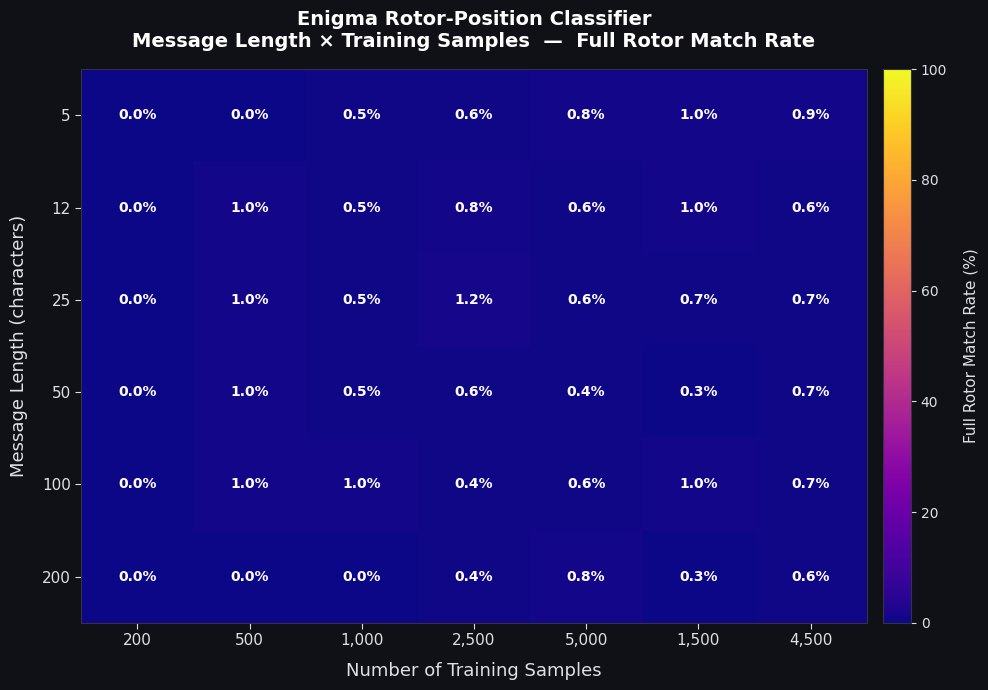


Done.


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import string
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import itertools
import json
from datetime import datetime

# Force file paths to be relative to the script location
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

INPUT_TEXT_FILE = os.path.join(BASE_DIR, 'The home book of verse processed.txt')

# Default Enigma configuration (same as original)
DEFAULT_ROTOR_ORDER = ['III', 'II', 'I']
DEFAULT_POSITIONS   = [0, 0, 0]

# ============================================================================
# GRID SEARCH CONFIGURATION
# ============================================================================
# Adjust these lists to change what gets tested.
# Each (message_length, num_samples) pair will be a separate training run.
MESSAGE_LENGTHS  = [5, 12, 25, 50, 100, 200]       # characters per training sample
NUM_SAMPLES_LIST = [200, 500, 1000, 2500, 5000, 1500, 4500]  # total training + validation samples

# Training hyper-parameters (kept fixed across all runs)
NUM_EPOCHS  = 30
BATCH_SIZE  = 32
HIDDEN_DIM  = 256   # FC layer width (same as original)
STEP_SIZE   = 50     # rotor advancement between consecutive samples

# ============================================================================
# ENIGMA SIMULATOR  (identical to original)
# ============================================================================
class SimpleEnigma:
    ROTORS = {
        'I':   'EKMFLGDQVZNTOWYHXUSPAIBRCJ',
        'II':  'AJDKSIRUXBLHWTMCQGZNPYFVOE',
        'III': 'BDFHJLCPRTXVZNYEIWGAKMUSQO',
        'IV':  'ESOVPZJAYQUIRHXLNFTGKDCMWB',
        'V':   'VZBRGITYUPSDNHLXAWMJQOFECK',
    }
    NOTCHES   = {'I': 'Q', 'II': 'E', 'III': 'V', 'IV': 'J', 'V': 'Z'}
    REFLECTOR = 'YRUHQSLDPXNGOKMIEBFZCWVJAT'

    def __init__(self, rotors, positions):
        self.rotors       = [self.ROTORS[r] for r in rotors]
        self.rotor_names  = rotors
        self.positions    = positions.copy()
        self.initial_positions = positions.copy()

    def reset(self):
        self.positions = self.initial_positions.copy()

    def set_positions(self, positions):
        self.positions = positions.copy()

    def get_positions(self):
        return self.positions.copy()

    def step_rotors(self):
        if self.rotor_at_notch(1):
            self.positions[1] = (self.positions[1] + 1) % 26
            self.positions[2] = (self.positions[2] + 1) % 26
        elif self.rotor_at_notch(0):
            self.positions[1] = (self.positions[1] + 1) % 26
        self.positions[0] = (self.positions[0] + 1) % 26

    def rotor_at_notch(self, rotor_index):
        notch     = self.NOTCHES[self.rotor_names[rotor_index]]
        notch_pos = ord(notch) - ord('A')
        return self.positions[rotor_index] == notch_pos

    def encrypt_char(self, char):
        if char not in string.ascii_uppercase:
            return char
        self.step_rotors()
        pos = ord(char) - ord('A')
        for i in range(3):
            pos = (pos + self.positions[i]) % 26
            pos = ord(self.rotors[i][pos]) - ord('A')
            pos = (pos - self.positions[i]) % 26
        pos = ord(self.REFLECTOR[pos]) - ord('A')
        for i in range(2, -1, -1):
            pos = (pos + self.positions[i]) % 26
            pos = self.rotors[i].index(chr(pos + ord('A')))
            pos = (pos - self.positions[i]) % 26
        return chr(pos + ord('A'))

    def encrypt(self, text):
        return ''.join(self.encrypt_char(c) for c in text.upper())


# ============================================================================
# DATA GENERATION
# ============================================================================
def read_text_from_file(filename):
    if not os.path.exists(filename):
        raise FileNotFoundError(f"Input file '{filename}' not found!")
    letters = []
    with open(filename, 'r') as f:
        for line in f:
            for char in line.strip().upper():
                if char in string.ascii_uppercase:
                    letters.append(char)
    text = ''.join(letters)
    print(f"  Read {len(text)} letters from '{filename}'")
    return text


def generate_dataset_continuous(full_plaintext, rotor_order, initial_positions,
                                num_samples, message_length, step_size=1):
    total_chars_needed = (num_samples * step_size) + message_length
    if len(full_plaintext) < total_chars_needed:
        repeats        = (total_chars_needed // len(full_plaintext)) + 1
        full_plaintext = full_plaintext * repeats

    enigma = SimpleEnigma(rotor_order, initial_positions)
    full_ciphertext = enigma.encrypt(full_plaintext)

    enigma.set_positions(initial_positions)
    data = []
    for i in range(num_samples):
        start_idx        = i * step_size
        plaintext        = full_plaintext [start_idx: start_idx + message_length]
        ciphertext       = full_ciphertext[start_idx: start_idx + message_length]
        chunk_positions  = enigma.get_positions()
        for char in full_plaintext[start_idx: start_idx + step_size]:
            if char in string.ascii_uppercase:
                enigma.step_rotors()
        data.append({
            'ciphertext': ciphertext,
            'plaintext':  plaintext,
            'rotors':     rotor_order,
            'positions':  chunk_positions,
        })
    return data


# ============================================================================
# PYTORCH DATASET
# ============================================================================
class EnigmaDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item             = self.data[idx]
        ciphertext_enc   = self.encode_text(item['ciphertext'])
        positions        = torch.tensor(item['positions'], dtype=torch.long)
        return ciphertext_enc, positions

    @staticmethod
    def encode_text(text):
        encoded = torch.zeros(len(text), 26)
        for i, char in enumerate(text):
            if char in string.ascii_uppercase:
                encoded[i, ord(char) - ord('A')] = 1
        return encoded


# ============================================================================
# MODEL  (identical architecture to original, same node counts)
# ============================================================================
class EnigmaRotorClassifier(nn.Module):
    def __init__(self, message_length=100, hidden_dim=1024):
        super().__init__()

        self.conv1 = nn.Conv1d(26,   64,   kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64,   128,  kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(128,  256,  kernel_size=3, padding=1)
        self.conv4 = nn.Conv1d(256,  512,  kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(512,  1024, kernel_size=3, padding=1)

        self.pool    = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)

        self.batch_norm1 = nn.BatchNorm1d(64)
        self.batch_norm2 = nn.BatchNorm1d(128)
        self.batch_norm3 = nn.BatchNorm1d(256)
        self.batch_norm4 = nn.BatchNorm1d(512)
        self.batch_norm5 = nn.BatchNorm1d(1024)

        self.relu = nn.ReLU()

        # Simulate the sequence length after each conv+pool step so the FC
        # input size is computed correctly regardless of message_length.
        # Pooling is skipped whenever the sequence would drop to 0.
        seq = message_length
        for _ in range(5):
            seq = seq // 2 if seq >= 2 else seq
        conv_output_size = max(seq, 1) * 1024

        self.fc1 = nn.Linear(conv_output_size, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim,       hidden_dim)

        self.rotor1_head = nn.Linear(hidden_dim, 26)
        self.rotor2_head = nn.Linear(hidden_dim, 26)
        self.rotor3_head = nn.Linear(hidden_dim, 26)

    @staticmethod
    def _pool_if_safe(pool, x):
        """Apply max-pool only when the sequence length is at least 2."""
        if x.size(2) >= 2:
            return pool(x)
        return x

    def forward(self, x):
        # x: (batch, seq_len, 26) → (batch, 26, seq_len)
        x = x.transpose(1, 2)

        x = self.relu(self.batch_norm1(self.conv1(x))); x = self._pool_if_safe(self.pool, x)
        x = self.relu(self.batch_norm2(self.conv2(x))); x = self._pool_if_safe(self.pool, x)
        x = self.relu(self.batch_norm3(self.conv3(x))); x = self._pool_if_safe(self.pool, x)
        x = self.relu(self.batch_norm4(self.conv4(x))); x = self._pool_if_safe(self.pool, x)
        x = self.relu(self.batch_norm5(self.conv5(x))); x = self._pool_if_safe(self.pool, x)

        x = x.view(x.size(0), -1)
        x = self.dropout(x)

        x = self.relu(self.fc1(x)); x = self.dropout(x)
        x = self.relu(self.fc2(x))

        return self.rotor1_head(x), self.rotor2_head(x), self.rotor3_head(x)


# ============================================================================
# SINGLE-RUN TRAINING  (returns best average validation accuracy across rotors)
# ============================================================================
def train_and_evaluate(message_length, num_samples, device, full_plaintext,
                       num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE,
                       hidden_dim=HIDDEN_DIM):
    print(f"\n  [MSG_LEN={message_length:>4d}, SAMPLES={num_samples:>5d}]  generating data …")

    dataset   = generate_dataset_continuous(
        full_plaintext   = full_plaintext,
        rotor_order      = DEFAULT_ROTOR_ORDER,
        initial_positions= DEFAULT_POSITIONS,
        num_samples      = num_samples,
        message_length   = message_length,
        step_size        = STEP_SIZE,
    )

    split_idx = int(0.8 * len(dataset))
    train_ds  = EnigmaDataset(dataset[:split_idx])
    val_ds    = EnigmaDataset(dataset[split_idx:])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=(device.type == 'cuda'))
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=0, pin_memory=(device.type == 'cuda'))

    model     = EnigmaRotorClassifier(message_length=message_length,
                                      hidden_dim=hidden_dim).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)

    best_avg_val_acc = 0.0

    for epoch in range(num_epochs):
        # --- training ---
        model.train()
        for ciphertext, positions in train_loader:
            ciphertext = ciphertext.to(device)
            positions  = positions.to(device)
            optimizer.zero_grad()
            o1, o2, o3 = model(ciphertext)
            loss = (criterion(o1, positions[:, 0]) +
                    criterion(o2, positions[:, 1]) +
                    criterion(o3, positions[:, 2]))
            loss.backward()
            optimizer.step()

        # --- validation ---
        model.eval()
        val_loss        = 0.0
        val_all_correct = 0   # samples where ALL THREE rotors are predicted correctly
        val_total       = 0
        with torch.no_grad():
            for ciphertext, positions in val_loader:
                ciphertext = ciphertext.to(device)
                positions  = positions.to(device)
                o1, o2, o3 = model(ciphertext)
                val_loss += (criterion(o1, positions[:, 0]) +
                             criterion(o2, positions[:, 1]) +
                             criterion(o3, positions[:, 2])).item()
                # A sample is only correct when every rotor prediction matches
                all_correct = (
                    (o1.argmax(1) == positions[:, 0]) &
                    (o2.argmax(1) == positions[:, 1]) &
                    (o3.argmax(1) == positions[:, 2])
                )
                val_all_correct += all_correct.sum().item()
                val_total       += positions.size(0)

        scheduler.step(val_loss)

        full_match_rate = (val_all_correct / val_total) * 100

        if full_match_rate > best_avg_val_acc:
            best_avg_val_acc = full_match_rate

        print(f"    Epoch {epoch+1:>2d}/{num_epochs}  "
              f"full_match={full_match_rate:.1f}%  "
              f"({val_all_correct}/{val_total} samples)  "
              f"best={best_avg_val_acc:.1f}%")

    return best_avg_val_acc


# ============================================================================
# HEATMAP PLOTTING
# ============================================================================
def plot_heatmap(results_grid, message_lengths, num_samples_list, save_path):
    """
    results_grid[i][j] = best avg val accuracy for
        message_lengths[i]  x  num_samples_list[j]
    """
    data_array = np.array(results_grid)   # shape: (len(ML), len(NS))

    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('#0f1117')
    ax.set_facecolor('#0f1117')

    # ---- colour map ----
    cmap = plt.cm.get_cmap('plasma')
    im   = ax.imshow(data_array, cmap=cmap, aspect='auto',
                     vmin=0, vmax=100, interpolation='nearest')

    # ---- axes ticks ----
    ax.set_xticks(range(len(num_samples_list)))
    ax.set_xticklabels([f'{n:,}' for n in num_samples_list],
                       color='#e0e0e0', fontsize=11)

    ax.set_yticks(range(len(message_lengths)))
    ax.set_yticklabels([str(m) for m in message_lengths],
                       color='#e0e0e0', fontsize=11)

    ax.set_xlabel('Number of Training Samples', color='#e0e0e0', fontsize=13, labelpad=10)
    ax.set_ylabel('Message Length (characters)',  color='#e0e0e0', fontsize=13, labelpad=10)

    ax.tick_params(colors='#e0e0e0', length=4)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333344')

    # ---- cell annotations ----
    for i in range(len(message_lengths)):
        for j in range(len(num_samples_list)):
            val      = data_array[i, j]
            txt_col  = 'white' if val < 60 else '#111111'
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                    fontsize=10, fontweight='bold', color=txt_col)

    # ---- colour bar ----
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label('Full Rotor Match Rate (%)',
                   color='#e0e0e0', fontsize=11, labelpad=12)
    cbar.ax.yaxis.set_tick_params(color='#e0e0e0')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#e0e0e0')
    cbar.outline.set_edgecolor('#333344')

    # ---- title ----
    ax.set_title('Enigma Rotor-Position Classifier\n'
                 'Message Length × Training Samples  —  Full Rotor Match Rate',
                 color='#ffffff', fontsize=14, fontweight='bold', pad=16)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    print(f"\n  Heatmap saved → {save_path}")
    plt.show()


# ============================================================================
# MAIN
# ============================================================================
if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')
    print(f'Grid: message_lengths={MESSAGE_LENGTHS}  ×  num_samples={NUM_SAMPLES_LIST}')
    print(f'Epochs per run: {NUM_EPOCHS} | Batch size: {BATCH_SIZE} | Hidden dim: {HIDDEN_DIM}')
    total_runs = len(MESSAGE_LENGTHS) * len(NUM_SAMPLES_LIST)
    print(f'Total training runs: {total_runs}\n')

    # Read the input file ONCE and reuse across all runs
    print('Loading input text file …')
    full_plaintext = read_text_from_file(INPUT_TEXT_FILE)
    print()

    # results_grid[i][j] corresponds to MESSAGE_LENGTHS[i], NUM_SAMPLES_LIST[j]
    results_grid = []
    run_number   = 0

    for i, msg_len in enumerate(MESSAGE_LENGTHS):
        row = []
        for j, n_samples in enumerate(NUM_SAMPLES_LIST):
            run_number += 1
            print(f"\n{'='*60}")
            print(f"RUN {run_number}/{total_runs}  |  "
                  f"msg_len={msg_len}  n_samples={n_samples}")
            print('='*60)

            best_acc = train_and_evaluate(
                message_length = msg_len,
                num_samples    = n_samples,
                device         = device,
                full_plaintext = full_plaintext,
            )
            row.append(best_acc)
            print(f"  → Best avg val accuracy: {best_acc:.2f}%")

        results_grid.append(row)

    # ---- save raw results ----
    timestamp    = datetime.now().strftime('%Y%m%d_%H%M%S')
    results_path = os.path.join(BASE_DIR, f'enigma_grid_results_{timestamp}.json')
    with open(results_path, 'w') as f:
        json.dump({
            'message_lengths':  MESSAGE_LENGTHS,
            'num_samples_list': NUM_SAMPLES_LIST,
            'results_grid':     results_grid,
            'timestamp':        timestamp,
        }, f, indent=2)
    print(f"\nRaw results saved → {results_path}")

    # ---- print summary table ----
    print('\n' + '='*60)
    print('RESULTS SUMMARY  (full rotor match rate %)')
    print('='*60)
    header = f"{'ML\\NS':>8}" + ''.join(f'{n:>10,}' for n in NUM_SAMPLES_LIST)
    print(header)
    print('-'*60)
    for i, msg_len in enumerate(MESSAGE_LENGTHS):
        row_str = f"{msg_len:>8}" + ''.join(f'{results_grid[i][j]:>9.2f}%'
                                             for j in range(len(NUM_SAMPLES_LIST)))
        print(row_str)

    # ---- plot heatmap ----
    heatmap_path = os.path.join(BASE_DIR, f'enigma_heatmap_{timestamp}.png')
    plot_heatmap(results_grid, MESSAGE_LENGTHS, NUM_SAMPLES_LIST, heatmap_path)

    print('\nDone.')

## validaiton

Using device: cuda
Grid: message_lengths=[4, 8, 12, 25, 50, 100, 200]  ×  num_samples=[1000, 2500, 5000, 15000, 45000]
Epochs per run: 6 | Batch size: 32 | Hidden dim: 256
Total training runs: 35

Loading input text file …
  Read 4396326 letters from 'C:\Users\acool\1 Capstone\Engima-Capstone-main\The home book of verse processed.txt'


RUN 1/35  |  msg_len=4  n_samples=1000

  [MSG_LEN=   4, SAMPLES= 1000]  generating data …
    Epoch  1/6  val_acc R1=4.0% R2=0.0% R3=0.0%  avg=1.3%  best=1.3%
    Epoch  2/6  val_acc R1=3.0% R2=0.0% R3=0.0%  avg=1.0%  best=1.3%
    Epoch  3/6  val_acc R1=0.5% R2=1.5% R3=0.5%  avg=0.8%  best=1.3%
    Epoch  4/6  val_acc R1=3.0% R2=1.5% R3=2.0%  avg=2.2%  best=2.2%
    Epoch  5/6  val_acc R1=3.0% R2=0.5% R3=0.5%  avg=1.3%  best=2.2%
    Epoch  6/6  val_acc R1=2.0% R2=2.0% R3=2.0%  avg=2.0%  best=2.2%
  → Best avg val accuracy: 2.17%

RUN 2/35  |  msg_len=4  n_samples=2500

  [MSG_LEN=   4, SAMPLES= 2500]  generating data …
    Epoch  1/6  val_acc R1=3.4%

C:\Users\acool\AppData\Local\Temp\ipykernel_30048\1931170259.py:333: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('plasma')



  Heatmap saved → C:\Users\acool\1 Capstone\Engima-Capstone-main\enigma_heatmap_20260323_211904.png


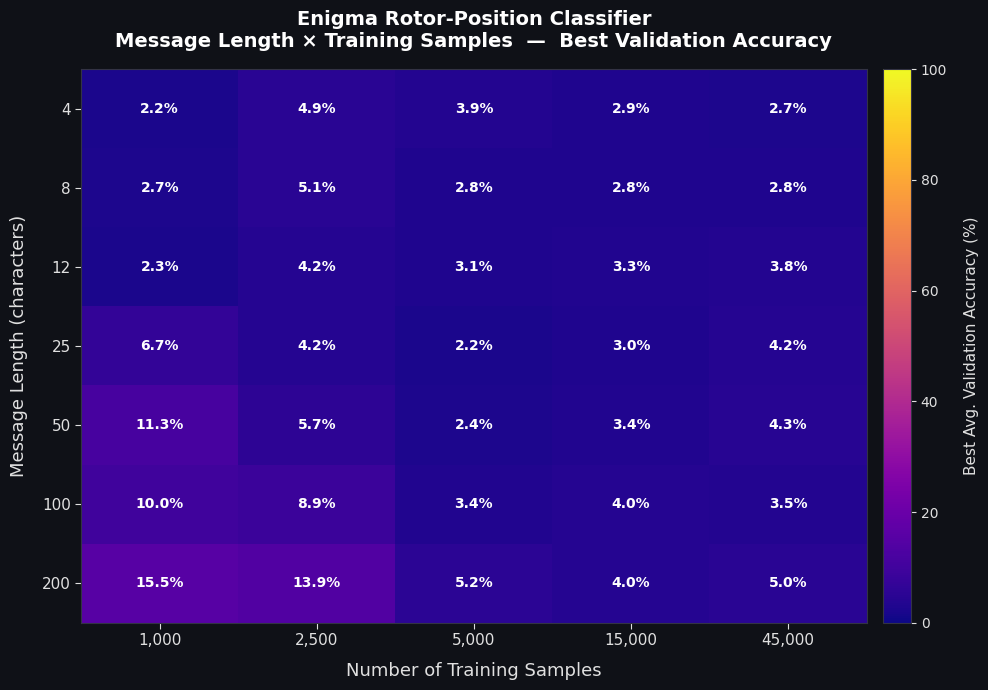


Done.


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import string
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import itertools
import json
from datetime import datetime

# Force file paths to be relative to the script location
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

INPUT_TEXT_FILE = os.path.join(BASE_DIR, 'The home book of verse processed.txt')

# Default Enigma configuration (same as original)
DEFAULT_ROTOR_ORDER = ['III', 'II', 'I']
DEFAULT_POSITIONS   = [0, 0, 0]

# ============================================================================
# GRID SEARCH CONFIGURATION
# ============================================================================
# Adjust these lists to change what gets tested.
# Each (message_length, num_samples) pair will be a separate training run.
MESSAGE_LENGTHS  = [4, 8, 12, 25, 50, 100, 200]       # characters per training sample
NUM_SAMPLES_LIST = [1000, 2500, 5000, 15000, 45000]  # total training + validation samples

# Training hyper-parameters (kept fixed across all runs)
NUM_EPOCHS  = 6
BATCH_SIZE  = 32
HIDDEN_DIM  = 256   # FC layer width (same as original)
STEP_SIZE   = 1     # rotor advancement between consecutive samples

# ============================================================================
# ENIGMA SIMULATOR  (identical to original)
# ============================================================================
class SimpleEnigma:
    ROTORS = {
        'I':   'EKMFLGDQVZNTOWYHXUSPAIBRCJ',
        'II':  'AJDKSIRUXBLHWTMCQGZNPYFVOE',
        'III': 'BDFHJLCPRTXVZNYEIWGAKMUSQO',
        'IV':  'ESOVPZJAYQUIRHXLNFTGKDCMWB',
        'V':   'VZBRGITYUPSDNHLXAWMJQOFECK',
    }
    NOTCHES   = {'I': 'Q', 'II': 'E', 'III': 'V', 'IV': 'J', 'V': 'Z'}
    REFLECTOR = 'YRUHQSLDPXNGOKMIEBFZCWVJAT'

    def __init__(self, rotors, positions):
        self.rotors       = [self.ROTORS[r] for r in rotors]
        self.rotor_names  = rotors
        self.positions    = positions.copy()
        self.initial_positions = positions.copy()

    def reset(self):
        self.positions = self.initial_positions.copy()

    def set_positions(self, positions):
        self.positions = positions.copy()

    def get_positions(self):
        return self.positions.copy()

    def step_rotors(self):
        if self.rotor_at_notch(1):
            self.positions[1] = (self.positions[1] + 1) % 26
            self.positions[2] = (self.positions[2] + 1) % 26
        elif self.rotor_at_notch(0):
            self.positions[1] = (self.positions[1] + 1) % 26
        self.positions[0] = (self.positions[0] + 1) % 26

    def rotor_at_notch(self, rotor_index):
        notch     = self.NOTCHES[self.rotor_names[rotor_index]]
        notch_pos = ord(notch) - ord('A')
        return self.positions[rotor_index] == notch_pos

    def encrypt_char(self, char):
        if char not in string.ascii_uppercase:
            return char
        self.step_rotors()
        pos = ord(char) - ord('A')
        for i in range(3):
            pos = (pos + self.positions[i]) % 26
            pos = ord(self.rotors[i][pos]) - ord('A')
            pos = (pos - self.positions[i]) % 26
        pos = ord(self.REFLECTOR[pos]) - ord('A')
        for i in range(2, -1, -1):
            pos = (pos + self.positions[i]) % 26
            pos = self.rotors[i].index(chr(pos + ord('A')))
            pos = (pos - self.positions[i]) % 26
        return chr(pos + ord('A'))

    def encrypt(self, text):
        return ''.join(self.encrypt_char(c) for c in text.upper())


# ============================================================================
# DATA GENERATION
# ============================================================================
def read_text_from_file(filename):
    if not os.path.exists(filename):
        raise FileNotFoundError(f"Input file '{filename}' not found!")
    letters = []
    with open(filename, 'r') as f:
        for line in f:
            for char in line.strip().upper():
                if char in string.ascii_uppercase:
                    letters.append(char)
    text = ''.join(letters)
    print(f"  Read {len(text)} letters from '{filename}'")
    return text


def generate_dataset_continuous(full_plaintext, rotor_order, initial_positions,
                                num_samples, message_length, step_size=1):
    total_chars_needed = (num_samples * step_size) + message_length
    if len(full_plaintext) < total_chars_needed:
        repeats        = (total_chars_needed // len(full_plaintext)) + 1
        full_plaintext = full_plaintext * repeats

    enigma = SimpleEnigma(rotor_order, initial_positions)
    full_ciphertext = enigma.encrypt(full_plaintext)

    enigma.set_positions(initial_positions)
    data = []
    for i in range(num_samples):
        start_idx        = i * step_size
        plaintext        = full_plaintext [start_idx: start_idx + message_length]
        ciphertext       = full_ciphertext[start_idx: start_idx + message_length]
        chunk_positions  = enigma.get_positions()
        for char in full_plaintext[start_idx: start_idx + step_size]:
            if char in string.ascii_uppercase:
                enigma.step_rotors()
        data.append({
            'ciphertext': ciphertext,
            'plaintext':  plaintext,
            'rotors':     rotor_order,
            'positions':  chunk_positions,
        })
    return data


# ============================================================================
# PYTORCH DATASET
# ============================================================================
class EnigmaDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item             = self.data[idx]
        ciphertext_enc   = self.encode_text(item['ciphertext'])
        positions        = torch.tensor(item['positions'], dtype=torch.long)
        return ciphertext_enc, positions

    @staticmethod
    def encode_text(text):
        encoded = torch.zeros(len(text), 26)
        for i, char in enumerate(text):
            if char in string.ascii_uppercase:
                encoded[i, ord(char) - ord('A')] = 1
        return encoded


# ============================================================================
# MODEL  (identical architecture to original, same node counts)
# ============================================================================
class EnigmaRotorClassifier(nn.Module):
    def __init__(self, message_length=100, hidden_dim=1024):
        super().__init__()

        self.conv1 = nn.Conv1d(26,   64,   kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64,   128,  kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(128,  256,  kernel_size=3, padding=1)
        self.conv4 = nn.Conv1d(256,  512,  kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(512,  1024, kernel_size=3, padding=1)

        self.pool    = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)

        self.batch_norm1 = nn.BatchNorm1d(64)
        self.batch_norm2 = nn.BatchNorm1d(128)
        self.batch_norm3 = nn.BatchNorm1d(256)
        self.batch_norm4 = nn.BatchNorm1d(512)
        self.batch_norm5 = nn.BatchNorm1d(1024)

        self.relu = nn.ReLU()

        # Simulate the sequence length after each conv+pool step so the FC
        # input size is computed correctly regardless of message_length.
        # Pooling is skipped whenever the sequence would drop to 0.
        seq = message_length
        for _ in range(5):
            seq = seq // 2 if seq >= 2 else seq
        conv_output_size = max(seq, 1) * 1024

        self.fc1 = nn.Linear(conv_output_size, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim,       hidden_dim)

        self.rotor1_head = nn.Linear(hidden_dim, 26)
        self.rotor2_head = nn.Linear(hidden_dim, 26)
        self.rotor3_head = nn.Linear(hidden_dim, 26)

    @staticmethod
    def _pool_if_safe(pool, x):
        """Apply max-pool only when the sequence length is at least 2."""
        if x.size(2) >= 2:
            return pool(x)
        return x

    def forward(self, x):
        # x: (batch, seq_len, 26) → (batch, 26, seq_len)
        x = x.transpose(1, 2)

        x = self.relu(self.batch_norm1(self.conv1(x))); x = self._pool_if_safe(self.pool, x)
        x = self.relu(self.batch_norm2(self.conv2(x))); x = self._pool_if_safe(self.pool, x)
        x = self.relu(self.batch_norm3(self.conv3(x))); x = self._pool_if_safe(self.pool, x)
        x = self.relu(self.batch_norm4(self.conv4(x))); x = self._pool_if_safe(self.pool, x)
        x = self.relu(self.batch_norm5(self.conv5(x))); x = self._pool_if_safe(self.pool, x)

        x = x.view(x.size(0), -1)
        x = self.dropout(x)

        x = self.relu(self.fc1(x)); x = self.dropout(x)
        x = self.relu(self.fc2(x))

        return self.rotor1_head(x), self.rotor2_head(x), self.rotor3_head(x)


# ============================================================================
# SINGLE-RUN TRAINING  (returns best average validation accuracy across rotors)
# ============================================================================
def train_and_evaluate(message_length, num_samples, device, full_plaintext,
                       num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE,
                       hidden_dim=HIDDEN_DIM):
    print(f"\n  [MSG_LEN={message_length:>4d}, SAMPLES={num_samples:>5d}]  generating data …")

    dataset   = generate_dataset_continuous(
        full_plaintext   = full_plaintext,
        rotor_order      = DEFAULT_ROTOR_ORDER,
        initial_positions= DEFAULT_POSITIONS,
        num_samples      = num_samples,
        message_length   = message_length,
        step_size        = STEP_SIZE,
    )

    split_idx = int(0.8 * len(dataset))
    train_ds  = EnigmaDataset(dataset[:split_idx])
    val_ds    = EnigmaDataset(dataset[split_idx:])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=(device.type == 'cuda'))
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=0, pin_memory=(device.type == 'cuda'))

    model     = EnigmaRotorClassifier(message_length=message_length,
                                      hidden_dim=hidden_dim).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)

    best_avg_val_acc = 0.0

    for epoch in range(num_epochs):
        # --- training ---
        model.train()
        for ciphertext, positions in train_loader:
            ciphertext = ciphertext.to(device)
            positions  = positions.to(device)
            optimizer.zero_grad()
            o1, o2, o3 = model(ciphertext)
            loss = (criterion(o1, positions[:, 0]) +
                    criterion(o2, positions[:, 1]) +
                    criterion(o3, positions[:, 2]))
            loss.backward()
            optimizer.step()

        # --- validation ---
        model.eval()
        val_loss    = 0.0
        val_correct = [0, 0, 0]
        val_total   = 0
        with torch.no_grad():
            for ciphertext, positions in val_loader:
                ciphertext = ciphertext.to(device)
                positions  = positions.to(device)
                o1, o2, o3 = model(ciphertext)
                val_loss += (criterion(o1, positions[:, 0]) +
                             criterion(o2, positions[:, 1]) +
                             criterion(o3, positions[:, 2])).item()
                for k, (o, col) in enumerate(zip([o1, o2, o3], range(3))):
                    val_correct[k] += (o.argmax(1) == positions[:, col]).sum().item()
                val_total += positions.size(0)

        scheduler.step(val_loss)

        val_accs    = [(c / val_total) * 100 for c in val_correct]
        avg_val_acc = sum(val_accs) / 3

        if avg_val_acc > best_avg_val_acc:
            best_avg_val_acc = avg_val_acc

        print(f"    Epoch {epoch+1:>2d}/{num_epochs}  "
              f"val_acc R1={val_accs[0]:.1f}% R2={val_accs[1]:.1f}% R3={val_accs[2]:.1f}%  "
              f"avg={avg_val_acc:.1f}%  best={best_avg_val_acc:.1f}%")

    return best_avg_val_acc


# ============================================================================
# HEATMAP PLOTTING
# ============================================================================
def plot_heatmap(results_grid, message_lengths, num_samples_list, save_path):
    """
    results_grid[i][j] = best avg val accuracy for
        message_lengths[i]  x  num_samples_list[j]
    """
    data_array = np.array(results_grid)   # shape: (len(ML), len(NS))

    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('#0f1117')
    ax.set_facecolor('#0f1117')

    # ---- colour map ----
    cmap = plt.cm.get_cmap('plasma')
    im   = ax.imshow(data_array, cmap=cmap, aspect='auto',
                     vmin=0, vmax=100, interpolation='nearest')

    # ---- axes ticks ----
    ax.set_xticks(range(len(num_samples_list)))
    ax.set_xticklabels([f'{n:,}' for n in num_samples_list],
                       color='#e0e0e0', fontsize=11)

    ax.set_yticks(range(len(message_lengths)))
    ax.set_yticklabels([str(m) for m in message_lengths],
                       color='#e0e0e0', fontsize=11)

    ax.set_xlabel('Number of Training Samples', color='#e0e0e0', fontsize=13, labelpad=10)
    ax.set_ylabel('Message Length (characters)',  color='#e0e0e0', fontsize=13, labelpad=10)

    ax.tick_params(colors='#e0e0e0', length=4)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333344')

    # ---- cell annotations ----
    for i in range(len(message_lengths)):
        for j in range(len(num_samples_list)):
            val      = data_array[i, j]
            txt_col  = 'white' if val < 60 else '#111111'
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                    fontsize=10, fontweight='bold', color=txt_col)

    # ---- colour bar ----
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label('Best Avg. Validation Accuracy (%)',
                   color='#e0e0e0', fontsize=11, labelpad=12)
    cbar.ax.yaxis.set_tick_params(color='#e0e0e0')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#e0e0e0')
    cbar.outline.set_edgecolor('#333344')

    # ---- title ----
    ax.set_title('Enigma Rotor-Position Classifier\n'
                 'Message Length × Training Samples  —  Best Validation Accuracy',
                 color='#ffffff', fontsize=14, fontweight='bold', pad=16)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    print(f"\n  Heatmap saved → {save_path}")
    plt.show()


# ============================================================================
# MAIN
# ============================================================================
if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')
    print(f'Grid: message_lengths={MESSAGE_LENGTHS}  ×  num_samples={NUM_SAMPLES_LIST}')
    print(f'Epochs per run: {NUM_EPOCHS} | Batch size: {BATCH_SIZE} | Hidden dim: {HIDDEN_DIM}')
    total_runs = len(MESSAGE_LENGTHS) * len(NUM_SAMPLES_LIST)
    print(f'Total training runs: {total_runs}\n')

    # Read the input file ONCE and reuse across all runs
    print('Loading input text file …')
    full_plaintext = read_text_from_file(INPUT_TEXT_FILE)
    print()

    # results_grid[i][j] corresponds to MESSAGE_LENGTHS[i], NUM_SAMPLES_LIST[j]
    results_grid = []
    run_number   = 0

    for i, msg_len in enumerate(MESSAGE_LENGTHS):
        row = []
        for j, n_samples in enumerate(NUM_SAMPLES_LIST):
            run_number += 1
            print(f"\n{'='*60}")
            print(f"RUN {run_number}/{total_runs}  |  "
                  f"msg_len={msg_len}  n_samples={n_samples}")
            print('='*60)

            best_acc = train_and_evaluate(
                message_length = msg_len,
                num_samples    = n_samples,
                device         = device,
                full_plaintext = full_plaintext,
            )
            row.append(best_acc)
            print(f"  → Best avg val accuracy: {best_acc:.2f}%")

        results_grid.append(row)

    # ---- save raw results ----
    timestamp    = datetime.now().strftime('%Y%m%d_%H%M%S')
    results_path = os.path.join(BASE_DIR, f'enigma_grid_results_{timestamp}.json')
    with open(results_path, 'w') as f:
        json.dump({
            'message_lengths':  MESSAGE_LENGTHS,
            'num_samples_list': NUM_SAMPLES_LIST,
            'results_grid':     results_grid,
            'timestamp':        timestamp,
        }, f, indent=2)
    print(f"\nRaw results saved → {results_path}")

    # ---- print summary table ----
    print('\n' + '='*60)
    print('RESULTS SUMMARY  (best avg val accuracy %)')
    print('='*60)
    header = f"{'ML\\NS':>8}" + ''.join(f'{n:>10,}' for n in NUM_SAMPLES_LIST)
    print(header)
    print('-'*60)
    for i, msg_len in enumerate(MESSAGE_LENGTHS):
        row_str = f"{msg_len:>8}" + ''.join(f'{results_grid[i][j]:>9.2f}%'
                                             for j in range(len(NUM_SAMPLES_LIST)))
        print(row_str)

    # ---- plot heatmap ----
    heatmap_path = os.path.join(BASE_DIR, f'enigma_heatmap_{timestamp}.png')
    plot_heatmap(results_grid, MESSAGE_LENGTHS, NUM_SAMPLES_LIST, heatmap_path)

    print('\nDone.')